In [ ]:
!pip install kagglehub scikit-learn matplotlib seaborn --quiet

import kagglehub
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.decomposition import PCA

print("All libraries loaded")

All libraries loaded


In [ ]:
path = kagglehub.dataset_download("humera11/cicbelldnsexf2021")
print("Dataset path:", path)

100%|██████████| 11.6M/11.6M [00:02<00:00, 5.61MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1


In [ ]:
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print("  ", f)

df_list = [pd.read_csv(f, low_memory=False) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
print(f"\nMerged shape: {df.shape}")

Found 36 CSV file(s):
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_3.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_1.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_1.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_2.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_3.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_2.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Attacks/stateful_features-heav

In [ ]:
label_col = None
for col in df.columns:
    if col.strip().lower() in ['label', 'class', 'target', 'attack_type', 'type']:
        label_col = col
        break
if label_col is None:
    label_col = df.columns[-1]

print(f"Label column: '{label_col}'")
print("\nClass distribution:")
print(df[label_col].value_counts())

Label column: 'subdomain'

Class distribution:
subdomain
1.0    529090
0.0    228121
Name: count, dtype: int64


In [ ]:
# Separate features and label
X = df.drop(columns=[label_col])
y_raw = df[label_col].copy()


In [ ]:
# Encode categorical feature columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

Categorical columns to encode: ['rr_type', 'distinct_ip', 'unique_country', 'unique_asn', 'distinct_domains', 'reverse_dns', 'unique_ttl', 'timestamp', 'longest_word', 'sld']


In [ ]:
#Clean up
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]
X = X.fillna(0)

In [ ]:
benign_label = None
for val in y_raw.unique():
    if 'benign' in str(val).lower() or 'normal' in str(val).lower():
        benign_label = val
        break
if benign_label is None:
    # Fall back to most frequent class
    benign_label = y_raw.value_counts().idxmax()

print(f"\nBenign class identified as: '{benign_label}'")
y_binary = (y_raw != benign_label).astype(int)   # 0=benign, 1=attack
print(f"Benign samples : {(y_binary==0).sum():,}")
print(f"Attack samples : {(y_binary==1).sum():,}")


Benign class identified as: '1.0'
Benign samples : 529,090
Attack samples : 490,226


In [ ]:
#Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFinal feature matrix: {X_scaled.shape}")


Final feature matrix: (1019316, 32)


In [ ]:
attack_fraction = (y_binary == 1).sum() / len(y_binary)
print(f"Attack fraction in dataset: {attack_fraction:.4f} ({attack_fraction*100:.1f}%)")

iso_forest = IsolationForest(
    n_estimators      = 200,
    max_samples       = 'auto',
    contamination     = attack_fraction,   # estimated anomaly fraction
    max_features      = 1.0,
    bootstrap         = False,
    random_state      = 42,
    n_jobs            = -1
)

print("Training Isolation Forest …")
iso_forest.fit(X_scaled)
print("Training complete ")

Attack fraction in dataset: 0.4809 (48.1%)
Training Isolation Forest …
Training complete 


In [ ]:
# sklearn convention: predict returns +1 (normal) or -1 (anomaly)
# We convert to:  0 = benign (normal), 1 = anomaly (attack)

raw_pred    = iso_forest.predict(X_scaled)       # +1 or -1
y_pred      = np.where(raw_pred == -1, 1, 0)     # 1=attack, 0=benign

anomaly_scores = -iso_forest.decision_function(X_scaled)

print("Prediction done")
print(f"Predicted anomalies : {y_pred.sum():,}")
print(f"Predicted benign    : {(y_pred==0).sum():,}")

Prediction done
Predicted anomalies : 490,226
Predicted benign    : 529,090


In [ ]:
print("CLASSIFICATION REPORT")
print(classification_report(y_binary, y_pred,
                             target_names=['Benign', 'Attack']))

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_binary, y_pred)
auc = roc_auc_score(y_binary, anomaly_scores)
ap  = average_precision_score(y_binary, anomaly_scores)

print(f"Overall Accuracy        : {acc*100:.2f}%")
print(f"AUC-ROC                 : {auc:.4f}")
print(f"Average Precision (AP)  : {ap:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.79      0.79      0.79    529090
      Attack       0.78      0.78      0.78    490226

    accuracy                           0.78   1019316
   macro avg       0.78      0.78      0.78   1019316
weighted avg       0.78      0.78      0.78   1019316

Overall Accuracy        : 78.37%
AUC-ROC                 : 0.8724
Average Precision (AP)  : 0.8382



 False Positive & False Negative Analysis 
  True Positives  (attacks caught)       : 379,981
  True Negatives  (benign correct)        : 418,845
  False Positives (benign flagged wrong)  : 110,245  FP Rate: 20.84%
  False Negatives (attacks missed)        : 110,245  FN Rate: 22.49%


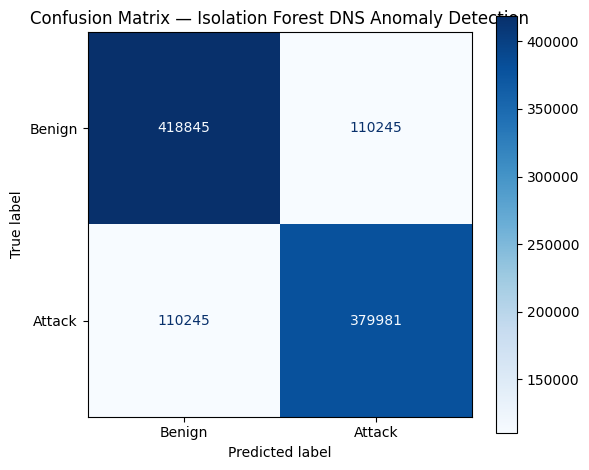

In [ ]:
cm = confusion_matrix(y_binary, y_pred)
TN, FP, FN, TP = cm.ravel()

print("\n False Positive & False Negative Analysis ")
print(f"  True Positives  (attacks caught)       : {TP:,}")
print(f"  True Negatives  (benign correct)        : {TN:,}")
print(f"  False Positives (benign flagged wrong)  : {FP:,}  FP Rate: {FP/(FP+TN)*100:.2f}%")
print(f"  False Negatives (attacks missed)        : {FN:,}  FN Rate: {FN/(FN+TP)*100:.2f}%")

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix — Isolation Forest DNS Anomaly Detection")
plt.tight_layout()
plt.savefig("iso_confusion_matrix.png", dpi=150)
plt.show()